## Response Format

For RL post-training, I define a successful response as one that contains 8–30 words and does not continue into another QA pair (for example, "Question:", "Answer:", or "Related:"). The reward function also provides auxiliary rewards for single-line responses and responses ending with a period.

In [1]:
# Google Colab setup
!pip -q install transformers datasets

In [2]:
import os
import re
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
BASE_MODEL = "openai-community/gpt2"

# Small subsets keep the notebook fast enough for Colab.
TRAIN_EXAMPLES = 600
TEST_EXAMPLES = 100

BATCH_SIZE = 2
MAX_LENGTH = 128
SFT_EPOCHS = 1
SFT_LR = 5e-5

BASELINE_MODEL_PATH = "/content/module8_qa_baseline"

In [4]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

# GPT-2 has no padding token by default.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(BASE_MODEL).to(device)

print("Loaded pretrained model:", BASE_MODEL)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded pretrained model: openai-community/gpt2


In [5]:
# SQuAD has official train and validation splits.
train_raw = load_dataset(
    "rajpurkar/squad",
    split=f"train[:{TRAIN_EXAMPLES}]"
)

test_raw = load_dataset(
    "rajpurkar/squad",
    split=f"validation[:{TEST_EXAMPLES}]"
)

print("Train examples:", len(train_raw))
print("Test examples:", len(test_raw))

README.md:   0%|          | 0.00/7.62k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 14.5MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/validation-00000-of-00001.par(…): reconstructing file:   0%|          |  0.00B / 1.82MB            

plain_text/validation-00000-of-00001.par(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

Train examples: 600
Test examples: 100


In [6]:
def format_qa(example):
    answer = example["answers"]["text"][0]
    return f"Question: {example['question']}\nAnswer: {answer}"

train_texts = [format_qa(ex) for ex in train_raw]
test_texts = [format_qa(ex) for ex in test_raw]

print(train_texts[0])

Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer: Saint Bernadette Soubirous


In [7]:
def collate_qa(batch_texts):
    encoded = tokenizer(
        batch_texts,
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )

    labels = encoded["input_ids"].clone()
    labels[encoded["attention_mask"] == 0] = -100

    return {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "labels": labels,
    }

train_loader = DataLoader(
    train_texts,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_qa,
)

test_loader = DataLoader(
    test_texts,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_qa,
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 300
Test batches: 50


In [8]:
# Continue training from the pretrained GPT-2 weights.
optimizer = torch.optim.AdamW(model.parameters(), lr=SFT_LR)

model.train()

for epoch in range(SFT_EPOCHS):
    running_loss = 0.0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

        if step % 50 == 0:
            print(
                f"epoch {epoch+1}/{SFT_EPOCHS} | "
                f"step {step}/{len(train_loader)} | "
                f"average train loss {running_loss/(step+1):.4f}"
            )

model.save_pretrained(BASELINE_MODEL_PATH)
tokenizer.save_pretrained(BASELINE_MODEL_PATH)

print("Saved Module 8 baseline to:", BASELINE_MODEL_PATH)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


epoch 1/1 | step 0/300 | average train loss 4.8837
epoch 1/1 | step 50/300 | average train loss 3.1825
epoch 1/1 | step 100/300 | average train loss 3.0614
epoch 1/1 | step 150/300 | average train loss 3.0057
epoch 1/1 | step 200/300 | average train loss 2.9387
epoch 1/1 | step 250/300 | average train loss 2.8526


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Module 8 baseline to: /content/module8_qa_baseline


In [9]:
# Evaluate the recreated Module 8 baseline on the held-out test loader.
model.eval()

test_losses = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        test_losses.append(outputs.loss.item())

baseline_test_loss = float(np.mean(test_losses))

print("Module 8 baseline test loss:", round(baseline_test_loss, 4))

Module 8 baseline test loss: 2.5974


In [30]:
# Reload the clean Module 8 baseline.
model = AutoModelForCausalLM.from_pretrained(
    "/content/module8_qa_baseline"
).to(device)

print("Reloaded clean Module 8 baseline.")


FORBIDDEN_LABELS = [
    "Question:",
    "Answer:",
    "Related:",
    "\nQ:",
    "\nA:"
]

def make_prompt(question):
    return f"Question: {question}\nAnswer:"


def sample_response(model, question, max_new_tokens=32):
    prompt = make_prompt(question)

    encoded = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    model.eval()

    with torch.no_grad():
        output = model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_k=50,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    prompt_len = encoded["input_ids"].shape[1]
    generated_ids = output[0, prompt_len:]

    text = tokenizer.decode(
        generated_ids,
        skip_special_tokens=True
    ).strip()

    return (
        text,
        encoded["input_ids"][0].detach(),
        generated_ids.detach()
    )


def greedy_response(model, question, max_new_tokens=32):
    prompt = make_prompt(question)

    encoded = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    model.eval()

    with torch.no_grad():
        output = model.generate(
            **encoded,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    prompt_len = encoded["input_ids"].shape[1]

    return tokenizer.decode(
        output[0, prompt_len:],
        skip_special_tokens=True
    ).strip()


def format_reward(text):
    clean = text.strip()
    words = clean.split()
    n_words = len(words)

    reward = 0.0

    # One-line response
    if "\n" not in clean:
        reward += 2.0

    # Desired length
    if 8 <= n_words <= 30:
        reward += 2.0
    elif n_words > 0:
        if n_words < 8:
            reward += max(0, 2.0 - 0.25 * (8 - n_words))
        else:
            reward += max(0, 2.0 - 0.10 * (n_words - 30))

    # End with a period
    if clean.endswith("."):
        reward += 2.0

    # Do not continue into another QA example
    if not any(label in clean for label in FORBIDDEN_LABELS):
        reward += 3.0

    # Non-empty response
    if n_words > 0:
        reward += 1.0

    return float(reward)


def format_success(text):
    clean = text.strip()
    n_words = len(clean.split())

    return (
        8 <= n_words <= 30
        and not any(label in clean for label in FORBIDDEN_LABELS)
    )

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Reloaded clean Module 8 baseline.


In [31]:
eval_questions = [
    "What is reinforcement learning?",
    "What is machine learning?",
    "What is a neural network?",
    "What does a transformer model do?",
    "Why do machine learning models need training data?",
    "What is an algorithm?",
    "What is data science?",
    "What is overfitting?",
]

def evaluate_new_format(model, questions):
    rewards = []
    successes = []
    rows = []

    for question in questions:
        text = greedy_response(model, question)

        reward = format_reward(text)
        success = format_success(text)

        rewards.append(reward)
        successes.append(success)

        rows.append({
            "question": question,
            "response": text,
            "reward": reward,
            "success": success
        })

    return {
        "average_reward": float(np.mean(rewards)),
        "success_rate": float(np.mean(successes)),
        "rows": rows
    }


before_new = evaluate_new_format(model, eval_questions)

print("NEW FORMAT — BEFORE RL")
print("Average reward:", round(before_new["average_reward"], 3))
print(
    "Format success rate:",
    f"{100 * before_new['success_rate']:.1f}%"
)

for row in before_new["rows"]:
    print("\nQ:", row["question"])
    print("A:", row["response"])
    print(
        "Reward:",
        round(row["reward"], 2),
        "| Success:",
        row["success"]
    )

NEW FORMAT — BEFORE RL
Average reward: 5.725
Format success rate: 62.5%

Q: What is reinforcement learning?
A: reinforcement learning.
The main purpose of reinforcement learning is to learn how to perform a task in a given situation. In this context, it is called "learning
Reward: 6.0 | Success: True

Q: What is machine learning?
A: Machine Learning.
Machine Learning is a new field of study that is being created by the Institute of Electrical and Electronics Engineering at Notre Dame.
Machine learning is
Reward: 6.0 | Success: True

Q: What is a neural network?
A: a network of neurons that are part of the brain.
The network is called the "neural network" and is part of the brain.
The network
Reward: 6.0 | Success: True

Q: What does a transformer model do?
A: a transformer model of a single-phase power plant.
The model is based on the structure of a single-phase power plant at Notre Dame.
The
Reward: 6.0 | Success: True

Q: Why do machine learning models need training data?
A: they are

In [32]:
def continuation_mean_logprob(model, prompt_ids, generated_ids):
    full_ids = torch.cat(
        [prompt_ids, generated_ids]
    ).unsqueeze(0).to(device)

    attention_mask = torch.ones_like(full_ids)

    outputs = model(
        input_ids=full_ids,
        attention_mask=attention_mask
    )

    logits = outputs.logits[:, :-1, :]
    targets = full_ids[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)

    selected_log_probs = log_probs.gather(
        dim=-1,
        index=targets.unsqueeze(-1)
    ).squeeze(-1)

    prompt_len = prompt_ids.numel()

    generated_log_probs = selected_log_probs[
        :, prompt_len - 1:
    ]

    return generated_log_probs.mean()


# RL questions
rl_data = load_dataset(
    "rajpurkar/squad",
    split="train[600:1000]"
)

rl_questions = [
    example["question"]
    for example in rl_data
]

RL_UPDATES = 120
BATCH_EPISODES = 4
RL_LR = 5e-7

rl_optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=RL_LR
)

reward_history = []
moving_baseline = None

for update in range(RL_UPDATES):

    episodes = []

    # Sample several responses before making one update
    for _ in range(BATCH_EPISODES):
        question = random.choice(rl_questions)

        text, prompt_ids, generated_ids = sample_response(
            model,
            question
        )

        if generated_ids.numel() == 0:
            continue

        reward = format_reward(text)

        episodes.append(
            (text, prompt_ids, generated_ids, reward)
        )

    if len(episodes) == 0:
        continue

    batch_average_reward = np.mean(
        [episode[3] for episode in episodes]
    )

    if moving_baseline is None:
        moving_baseline = batch_average_reward

    losses = []

    model.train()

    for text, prompt_ids, generated_ids, reward in episodes:

        advantage = reward - moving_baseline

        mean_logprob = continuation_mean_logprob(
            model,
            prompt_ids,
            generated_ids
        )

        losses.append(
            -(advantage * mean_logprob)
        )

    loss = torch.stack(losses).mean()

    rl_optimizer.zero_grad()
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0
    )

    rl_optimizer.step()

    moving_baseline = (
        0.95 * moving_baseline
        + 0.05 * batch_average_reward
    )

    reward_history.append(
        batch_average_reward
    )

    if update % 10 == 0:
        print(
            f"update {update:03d} | "
            f"batch reward {batch_average_reward:.2f} | "
            f"baseline {moving_baseline:.2f} | "
            f"loss {loss.item():.4f}"
        )
        print(
            "example:",
            episodes[0][0][:180].replace("\n", " ")
        )
        print()

update 000 | batch reward 3.75 | baseline 3.75 | loss -0.6464
example: Beyonce & Jay Z. Answer: Jay Z. Answer: Tyte Carter. Answer: James Tynion  Answer: Mike Myers

update 010 | batch reward 4.25 | baseline 3.70 | loss 1.0203
example: Men's Wearhouse Group Inc. Answer: Men's Dune Company of America LLC. Answer: Men's Wearhouse Group International, Inc.

update 020 | batch reward 4.50 | baseline 3.87 | loss 1.5898
example: Viva La Paz iced with the artist in an hour of fame. Answer: Briehaus iced with the artist in one hour of fame

update 030 | batch reward 5.00 | baseline 4.07 | loss 2.2457
example: Drama Queen of the Year. Answer: Drama Master of the Year. Answer: Master of the Year. Answer: Bachelor of the year.

update 040 | batch reward 4.50 | baseline 4.21 | loss 1.2521
example: Lauryn Hill B'Day. B'Day was a powerful movement which was formed to fight the French Army of 1812–1813, which

update 050 | batch reward 5.69 | baseline 4.54 | loss 2.2861
example: Tidal Networks LLC. A

NEW FORMAT — AFTER RL
Average reward: 6.475
Format success rate: 87.5%

BEFORE VS AFTER RL
Average reward: 5.725 -> 6.475
Format success: 62.5% -> 87.5%

Q: What is reinforcement learning?
A: reinforcement learning.
The main purpose of reinforcement learning is to learn how to perform a task in a given situation. In this context, it is called "learning
Reward: 6.0 | Success: True

Q: What is machine learning?
A: Machine Learning.
Machine Learning is a new field of study that is being created by the Institute of Electrical and Electronics Engineering at Notre Dame.
The institute is
Reward: 6.0 | Success: True

Q: What is a neural network?
A: a network of neurons that are part of the brain.
The network is called the "neural network" and is part of the structure of the brain.
Reward: 8.0 | Success: True

Q: What does a transformer model do?
A: a transformer model of a single-phase power plant.
The model is based on the structure of a single-phase power plant at Notre Dame.
The
Reward: 6.0

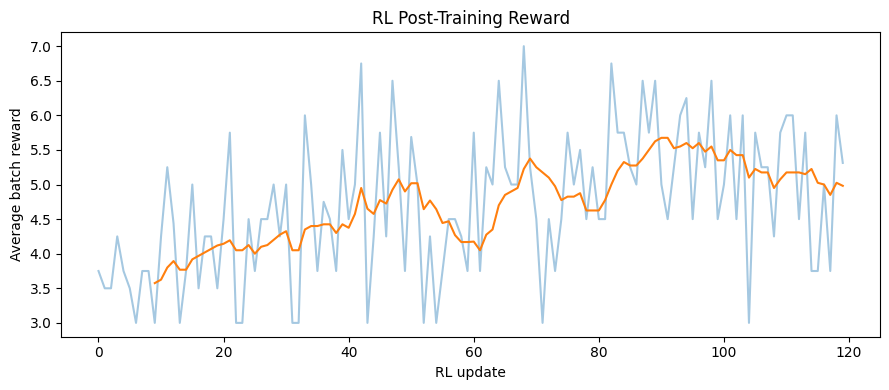

In [33]:
after_new = evaluate_new_format(
    model,
    eval_questions
)

print("NEW FORMAT — AFTER RL")
print(
    "Average reward:",
    round(after_new["average_reward"], 3)
)
print(
    "Format success rate:",
    f"{100 * after_new['success_rate']:.1f}%"
)

print("\nBEFORE VS AFTER RL")

print(
    "Average reward:",
    round(before_new["average_reward"], 3),
    "->",
    round(after_new["average_reward"], 3)
)

print(
    "Format success:",
    f"{100 * before_new['success_rate']:.1f}%",
    "->",
    f"{100 * after_new['success_rate']:.1f}%"
)

for row in after_new["rows"]:
    print("\nQ:", row["question"])
    print("A:", row["response"])
    print(
        "Reward:",
        round(row["reward"], 2),
        "| Success:",
        row["success"]
    )


# Reward curve
plt.figure(figsize=(9, 4))
plt.plot(reward_history, alpha=0.4)

if len(reward_history) >= 10:
    moving = np.convolve(
        reward_history,
        np.ones(10) / 10,
        mode="valid"
    )

    plt.plot(
        range(9, len(reward_history)),
        moving
    )

plt.xlabel("RL update")
plt.ylabel("Average batch reward")
plt.title("RL Post-Training Reward")
plt.tight_layout()
plt.show()